# Proyek Pemodelan & Simulasi: Segmentasi Pelanggan Olist Brasil
**Algoritma:** K-Medoids (Varian CLARA)

---
## Identitas Kelompok & Pembagian Peran (Sesuai Kriteria P41/P42/R4)

| Peran | Mahasiswa | Kode Tugas | Fokus Utama |
| :--- | :--- | :--- | :--- |
| **Data Architect & Engineer** | [Nama Mahasiswa 1] | P41, P42, R4 | Ingestion, Merging, RFM Engineering, Scaling, Elbow Method |
| **Model Analyst & Strategist** | [Nama Mahasiswa 2] | P41, P42, R4 | CLARA Implementation, Silhouette Score, Profiling, Jaccard Test, Simulator |

---
## 1. Persiapan Lingkungan

In [22]:
!pip install scikit-learn-extra pandas numpy matplotlib seaborn scikit-learn setuptools "numpy<2"

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, jaccard_score
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids, CLARA
import warnings
warnings.filterwarnings('ignore')

---
## BAGIAN I: DATA ARCHITECT & ENGINEER (MAHASISWA 1)
**Fokus:** Integrasi data relasional, rekayasa fitur RFM, dan optimalisasi kelompok.

### 2. Data Ingestion & Merging
Menggabungkan tabel `customers`, `orders`, dan `payments`.

In [24]:
# Load Datasets
customers = pd.read_csv('brazilian_e_commerce/olist_customers_dataset.csv')
orders = pd.read_csv('brazilian_e_commerce/olist_orders_dataset.csv')
payments = pd.read_csv('brazilian_e_commerce/olist_order_payments_dataset.csv')

# Merging
df = orders.merge(customers, on='customer_id')
df = df.merge(payments, on='order_id')

print(f"Data terintegrasi: {df.shape[0]} baris")
df.head()

Data terintegrasi: 103886 baris


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12


### 3. RFM Engineering
Menciptakan fitur baru: Recency, Frequency, dan Monetary.

In [25]:
# Konversi tipe data waktu
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Penentuan tanggal referensi (H+1 dari transaksi terakhir)
ref_date = df['order_purchase_timestamp'].max() + timedelta(days=1)

# Agregasi RFM
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (ref_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
})

rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


### 4. Outlier Filtering & Feature Scaling
Membersihkan data ekstrem dan melakukan standarisasi agar kriteria hari dan jutaan dapat diperbandingkan secara adil.

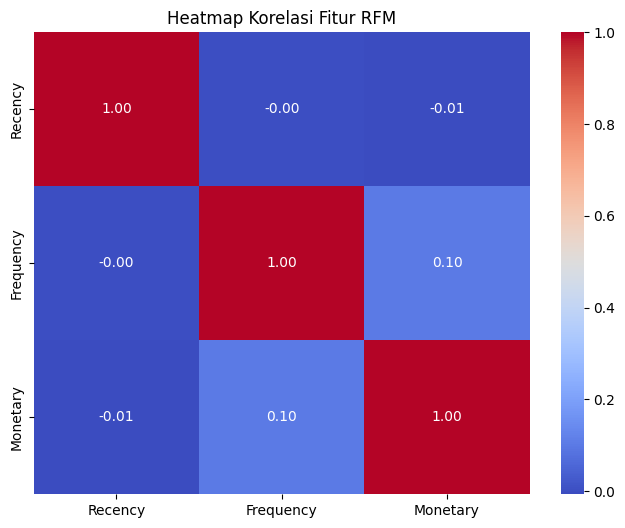

Data setelah filter outlier: 94812 pelanggan


In [26]:
# Filter Outliers menggunakan IQR
Q1 = rfm.quantile(0.05)
Q3 = rfm.quantile(0.95)
IQR = Q3 - Q1
rfm_clean = rfm[~((rfm < (Q1 - 1.5 * IQR)) | (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]

# Visualisasi Korelasi (Analisis RFM)
plt.figure(figsize=(8, 6))
sns.heatmap(rfm_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur RFM')
plt.show()

# Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_clean.index, columns=rfm_clean.columns)

print(f"Data setelah filter outlier: {rfm_clean.shape[0]} pelanggan")

### 5. Identification Phase: Elbow Method (Optimization)
Menjalankan perulangan untuk mencari jumlah klaster (K) terbaik.

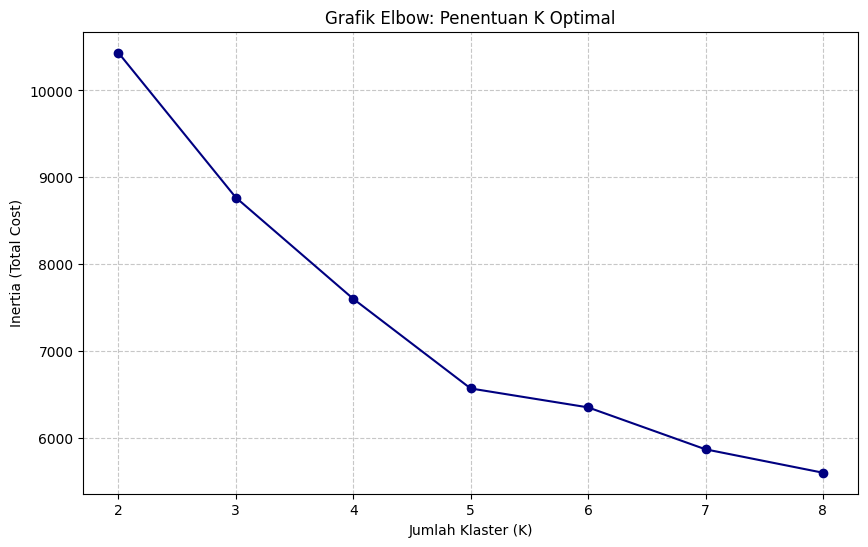

In [27]:
inertia = []
K_range = range(2, 9)
rfm_sample = rfm_scaled_df.sample(n=min(10000, len(rfm_scaled_df)), random_state=42)

for k in K_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42, init='k-medoids++')
    kmedoids.fit(rfm_sample)
    inertia.append(kmedoids.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', color='navy')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia (Total Cost)')
plt.title('Grafik Elbow: Penentuan K Optimal')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

---
## BAGIAN II: MODEL ANALYST & STRATEGIST (MAHASISWA 2)
**Fokus:** Validasi kualitas klaster, profilisasi segmen, dan uji stabilitas sistem.

### 6. Model Implementation (CLARA) & PCA Visualization
Menerapkan algoritma clustering pada fitur RFM dan visualisasi sebaran 2D.

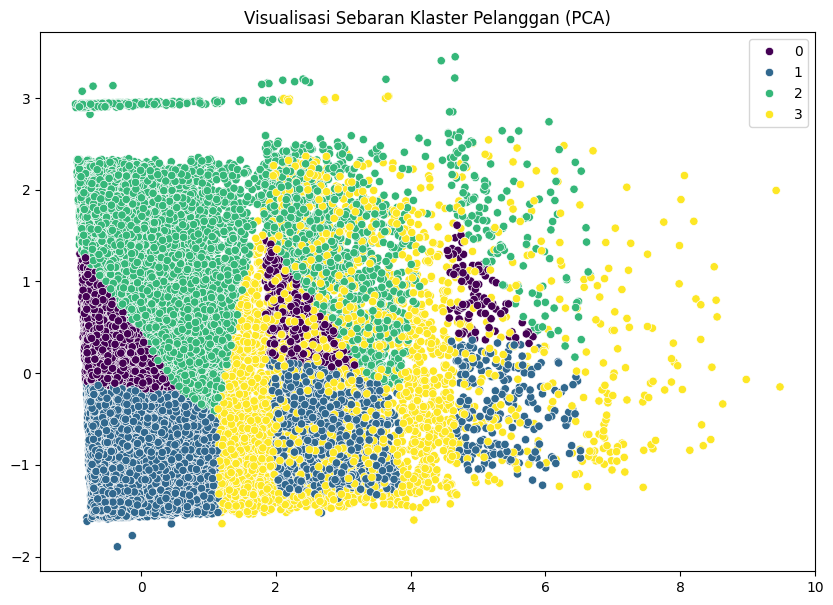

Quality Audit (Silhouette Score): 0.2551


In [28]:
best_k = 4 
final_model = CLARA(n_clusters=best_k, random_state=42)
clusters = final_model.fit_predict(rfm_scaled)
rfm_clean['Cluster'] = clusters

# PCA for 2D Visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Visualisasi Sebaran Klaster Pelanggan (PCA)')
plt.show()

# Quality Audit: Silhouette Score
sil_score = silhouette_score(rfm_sample, final_model.predict(rfm_sample))
print(f"Quality Audit (Silhouette Score): {sil_score:.4f}")

### 7. Profiling & Labeling
Memberikan interpretasi logis dan nama pada setiap kelompok.

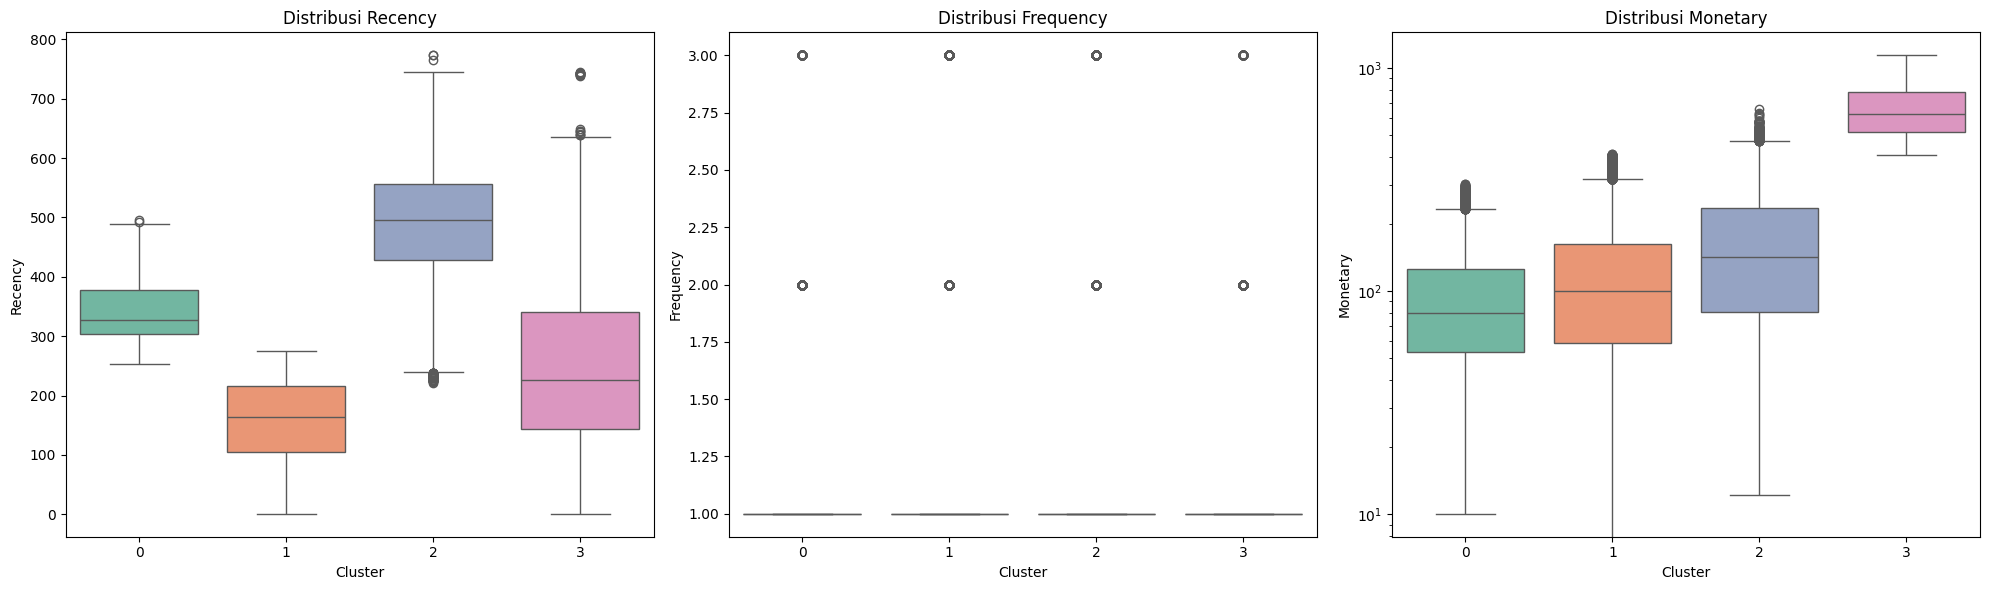

                             Recency  Frequency  Monetary
Segment                                                  
Pelanggan Lama (At Risk)      486.99       1.07    170.58
Pelanggan Setia (Champions)   342.43       1.05     93.95
Sering Belanja, Nilai Kecil   255.41       1.13    662.13
Sultan (High Spenders)        160.96       1.05    120.54


In [29]:
features = ['Recency', 'Frequency', 'Monetary']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, feature in enumerate(features):
    sns.boxplot(x='Cluster', y=feature, data=rfm_clean, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {feature}')
    if feature == 'Monetary': axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

# Cluster Labeling
cluster_names = {
    0: 'Pelanggan Setia (Champions)',
    1: 'Sultan (High Spenders)',
    2: 'Pelanggan Lama (At Risk)',
    3: 'Sering Belanja, Nilai Kecil'
}
rfm_clean['Segment'] = rfm_clean['Cluster'].map(cluster_names)
print(rfm_clean.groupby('Segment')[features].mean().round(2))

### 8. Stability Testing (Jaccard Index)
Menguji stabilitas segmen dengan penambahan noise pada data.

In [30]:
def calculate_jaccard(data, original_labels, noise_level=0.01):
    noise = np.random.normal(0, noise_level, data.shape)
    data_noisy = data + noise
    new_model = CLARA(n_clusters=best_k, random_state=42)
    new_labels = new_model.fit_predict(data_noisy)
    return jaccard_score(original_labels, new_labels, average='macro')

jaccard_val = calculate_jaccard(rfm_scaled, clusters)
print(f"Hasil Uji Stabilitas (Jaccard Index): {jaccard_val:.4f}")

Hasil Uji Stabilitas (Jaccard Index): 0.2545


### 9. Business Simulation & Strategy
Simulasi kebijakan marketing berdasarkan kelompok yang ditemukan.

### 10. Simulator Aplikasi
Modul simulator kategori pelanggan (Uji dengan 10 sampel).

In [31]:
def predict_segment(r, f, m):
    input_data = np.array([[r, f, m]])
    input_scaled = scaler.transform(input_data)
    cluster = final_model.predict(input_scaled)[0]
    segment = cluster_names[cluster]
    
    recommendations = {
        'Pelanggan Setia (Champions)': 'Berikan program loyalty eksklusif.',
        'Pelanggan Lama (At Risk)': 'Kirimkan email re-engagement dan diskon win-back.',
        'Sultan (High Spenders)': 'Tawarkan produk premium atau bundling.',
        'Sering Belanja, Nilai Kecil': 'Berikan promo free shipping dengan minimal belanja.'
    }
    return segment, recommendations.get(segment, "N/A")

print("=== TESTING SIMULATOR (10 SAMPEL ACAK) ===")
samples = rfm_clean.sample(10)
for idx, row in samples.iterrows():
    seg, rec = predict_segment(row['Recency'], row['Frequency'], row['Monetary'])
    print(f"Pelanggan {idx[:8]}: Segmen={seg} | Rekomendasi={rec}")

=== TESTING SIMULATOR (10 SAMPEL ACAK) ===
Pelanggan a0565e3f: Segmen=Pelanggan Lama (At Risk) | Rekomendasi=Kirimkan email re-engagement dan diskon win-back.
Pelanggan 43edb847: Segmen=Sultan (High Spenders) | Rekomendasi=Tawarkan produk premium atau bundling.
Pelanggan d1dc4ed1: Segmen=Sultan (High Spenders) | Rekomendasi=Tawarkan produk premium atau bundling.
Pelanggan 3c569102: Segmen=Sering Belanja, Nilai Kecil | Rekomendasi=Berikan promo free shipping dengan minimal belanja.
Pelanggan a63af578: Segmen=Sultan (High Spenders) | Rekomendasi=Tawarkan produk premium atau bundling.
Pelanggan 995a4b5f: Segmen=Pelanggan Setia (Champions) | Rekomendasi=Berikan program loyalty eksklusif.
Pelanggan b1629061: Segmen=Pelanggan Setia (Champions) | Rekomendasi=Berikan program loyalty eksklusif.
Pelanggan b9fd8892: Segmen=Sultan (High Spenders) | Rekomendasi=Tawarkan produk premium atau bundling.
Pelanggan eedcd29d: Segmen=Pelanggan Setia (Champions) | Rekomendasi=Berikan program loyalty eksklus